In [105]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [106]:
!pip install sentence-transformers -q

In [107]:
!pip install wandb -q
import wandb
wandb.login()

True

In [108]:
run = wandb.init(
    entity  = "24f1001025-indian-institute-of-technology-madras",
    project = "24f1001025-t22026",
    name    = "bert-finetuned-mcq",
    config  = {
        "model"        : "bert-base-uncased",
        "learning_rate": 2e-5,
        "epochs"       : 3,
        "batch_size"   : 16,
        "max_length"   : 256,
        "dataset"      : "smart-mcq-solver",
        "task"         : "MCQ classification"
    }
)
print('wandb run started!')
print(f'Run URL: {run.url}')

wandb run started!
Run URL: https://wandb.ai/24f1001025-indian-institute-of-technology-madras/24f1001025-t22026/runs/j2a6d1ef


In [109]:
import pandas as pd
import numpy as np
import string
import torch
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using device:', device)

# Load dataset
train_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
train_df.head(3)

using device: cuda
Train shape : (2000, 8)
Test shape  : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


In [110]:
import pandas as pd
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from transformers import pipeline

# checking if gpu is available
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU available: True
Device: Tesla T4


In [111]:
# loading train and test data
train_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

print(f'train shape: {train_df.shape}')
print(f'test shape : {test_df.shape}')
train_df.head(3)

train shape: (2000, 8)
test shape : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


In [112]:
# MAP@3 function - used for evaluating all models
# it gives higher score if correct answer appears earlier in prediction
def map_at_3(prediction, ground_truth):
    for k, pred in enumerate(prediction[:3], start=1):
        if pred == ground_truth:
            return round(1.0 / k, 4)
    return 0.0

def evaluate_map3(predictions_dict, df):
    """calculate average MAP@3 on train data"""
    scores = []
    for idx, row in df.iterrows():
        top3  = predictions_dict[idx]
        score = map_at_3(top3, row['answer'].strip())
        scores.append(score)
    return round(np.mean(scores), 4)

print('helper functions ready!')

helper functions ready!


---
## Model 1 — TF-IDF Cosine Similarity (Baseline)

This is the simplest approach. i am converting text to TF-IDF vectors and finding
which option is most similar to the prompt using cosine similarity.
The problem with this approach is it only matches words, not meaning.

In [113]:
# combining prompt + all options into one document per row
# then fitting tfidf on this combined text
train_df['combined'] = (
    train_df['prompt'] + ' ' + train_df['A'] + ' ' +
    train_df['B']      + ' ' + train_df['C'] + ' ' +
    train_df['D']      + ' ' + train_df['E']
)

tfidf = TfidfVectorizer(stop_words='english')
tfidf.fit(train_df['combined'])

print(f'vocabulary size: {len(tfidf.vocabulary_)}')

vocabulary size: 2762


In [114]:
# predicting top 3 options for each row using cosine similarity
model1_train_preds = {}

for idx, row in train_df.iterrows():
    prompt_vec = tfidf.transform([str(row['prompt'])])
    sims = {}
    for opt in ['A','B','C','D','E']:
        opt_vec   = tfidf.transform([str(row[opt])])
        sims[opt] = cosine_similarity(prompt_vec, opt_vec)[0][0]
    top3 = sorted(sims, key=sims.get, reverse=True)[:3]
    model1_train_preds[idx] = top3

# calculating MAP@3 on train
m1_scores = [map_at_3(model1_train_preds[i], train_df.iloc[i]['answer'].strip())
             for i in range(len(train_df))]
model1_map3 = round(np.mean(m1_scores), 4)
print(f'Model 1 (TF-IDF) Train MAP@3 = {model1_map3}')

Model 1 (TF-IDF) Train MAP@3 = 0.2962


In [115]:
# generating test predictions for model 1
model1_test_preds = []
for _, row in test_df.iterrows():
    prompt_vec = tfidf.transform([str(row['prompt'])])
    sims = {}
    for opt in ['A','B','C','D','E']:
        opt_vec   = tfidf.transform([str(row[opt])])
        sims[opt] = cosine_similarity(prompt_vec, opt_vec)[0][0]
    top3 = sorted(sims, key=sims.get, reverse=True)[:3]
    model1_test_preds.append(' '.join(top3))

print(f'model 1 test predictions: {len(model1_test_preds)}')
print(f'sample: {model1_test_preds[:3]}')

model 1 test predictions: 500
sample: ['A B C', 'A B C', 'A D C']


---
## Model 2 — BART Zero-shot Classification

**How it works:**
- BART is a large pre-trained transformer model (400M parameters)
- Zero-shot means no fine-tuning needed — model is used as-is
- We pass the prompt and ask model to score each option
- Uses Natural Language Inference (NLI) to find best answer

**Why better than TF-IDF:** BART understands meaning, not just words.

**Expected Score:** ~0.49

In [116]:
# loading facebook/bart-large-mnli
# mnli = Multi-Genre Natural Language Inference
# this model can judge if a statement is true given a context
print('loading BART model...')
bart_classifier = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=0   # using GPU
)
print('BART loaded!')

loading BART model...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

BART loaded!


In [117]:
# validating bart on 200 train rows
print('validating BART on 200 train rows...')
bart_scores = []

for idx in range(200):
    row     = train_df.iloc[idx]
    prompt  = str(row['prompt'])
    options = {'A': str(row['A']), 'B': str(row['B']), 'C': str(row['C']),
               'D': str(row['D']), 'E': str(row['E'])}

    result  = bart_classifier(
        prompt,
        candidate_labels=list(options.values()),
        hypothesis_template='The correct answer to this question is: {}'
    )

    # mapping text back to letter
    text_to_letter = {v: k for k, v in options.items()}
    ranked = [text_to_letter[l] for l in result['labels']]
    score  = map_at_3(ranked[:3], row['answer'].strip())
    bart_scores.append(score)

    if (idx+1) % 50 == 0:
        print(f'  {idx+1}/200 — MAP@3: {round(np.mean(bart_scores), 4)}')

model2_map3 = round(np.mean(bart_scores), 4)
print(f'\nModel 2 (BART) Validation MAP@3 = {model2_map3}')

validating BART on 200 train rows...
  50/200 — MAP@3: 0.53
  100/200 — MAP@3: 0.5683
  150/200 — MAP@3: 0.5811
  200/200 — MAP@3: 0.5983

Model 2 (BART) Validation MAP@3 = 0.5983


In [118]:
# generating test predictions using BART
print('generating BART test predictions...')
model2_test_preds = []

for i, (_, row) in enumerate(test_df.iterrows()):
    options = {'A': str(row['A']), 'B': str(row['B']), 'C': str(row['C']),
               'D': str(row['D']), 'E': str(row['E'])}
    result  = bart_classifier(
        str(row['prompt']),
        candidate_labels=list(options.values()),
        hypothesis_template='The correct answer to this question is: {}'
    )
    text_to_letter = {v: k for k, v in options.items()}
    ranked = [text_to_letter[l] for l in result['labels']]
    model2_test_preds.append(' '.join(ranked[:3]))
    if (i+1) % 50 == 0:
        print(f'  {i+1}/500 done')

print(f'model 2 test predictions done: {len(model2_test_preds)}')

generating BART test predictions...
  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done
  500/500 done
model 2 test predictions done: 500


---
## Model 3 — BERT Fine-tuning (Best Model)

**How it works:**
- BERT (Bidirectional Encoder Representations from Transformers) is loaded
- We add a classification head on top — 5 output classes (A, B, C, D, E)
- BERT is trained on our actual MCQ training data for 3 epochs
- After training, it learns patterns from 2000 questions

**Why best:** Unlike zero-shot models, BERT actually learns from our data.

**Input format:** `Question: [prompt] A: [optA] B: [optB] C: [optC] D: [optD] E: [optE]`

**Expected Score:** 0.73+

In [119]:
# converting answer letters to numbers for training
# neural networks need numeric labels, not text
label_map = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4}
inv_label = {0:'A', 1:'B', 2:'C', 3:'D', 4:'E'}

train_df['label'] = train_df['answer'].map(label_map)
print('label distribution:')
print(train_df['label'].value_counts().sort_index())

label distribution:
label
0    369
1    490
2    459
3    358
4    324
Name: count, dtype: int64


In [120]:
# loading BERT tokenizer
# tokenizer converts text to numbers that BERT understands
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
print('tokenizer loaded!')

# example of what tokenizer does
sample = tokenizer('Hello World', return_tensors='pt')
print(f'sample input_ids: {sample["input_ids"]}')

tokenizer loaded!
sample input_ids: tensor([[ 101, 7592, 2088,  102]])


In [121]:
# custom dataset class for feeding data to BERT
# each sample = full question with all 5 options combined

class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, is_test=False):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.is_test   = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # combining question + all options as one input
        text = (f"Question: {row['prompt']} "
                f"A: {row['A']} B: {row['B']} "
                f"C: {row['C']} D: {row['D']} E: {row['E']}")

        enc  = self.tokenizer(text, max_length=256, padding='max_length',
                              truncation=True, return_tensors='pt')

        item = {'input_ids'     : enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze()}

        if not self.is_test:
            item['label'] = torch.tensor(row['label'], dtype=torch.long)
        return item

print('MCQDataset class ready!')

MCQDataset class ready!


In [122]:
# splitting data: 90% train, 10% validation
# validation is used to check model performance during training
train_data, val_data = train_test_split(
    train_df, test_size=0.1, random_state=42, stratify=train_df['label']
)
print(f'training samples  : {len(train_data)}')
print(f'validation samples: {len(val_data)}')

# dataloader feeds data in batches to GPU
train_loader = DataLoader(MCQDataset(train_data, tokenizer), batch_size=16, shuffle=True)
val_loader   = DataLoader(MCQDataset(val_data,   tokenizer), batch_size=16, shuffle=False)
test_loader  = DataLoader(MCQDataset(test_df,    tokenizer, is_test=True), batch_size=16, shuffle=False)

print('dataloaders ready!')

training samples  : 1800
validation samples: 200
dataloaders ready!


In [123]:
# loading BERT with a classification head
# num_labels=5 because we predict one of 5 options (A,B,C,D,E)
model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=5
)
model = model.to(device)
print('BERT model loaded on GPU!')

# AdamW optimizer — standard for fine-tuning transformers
# lr=2e-5 is small learning rate to avoid forgetting pre-trained knowledge
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = len(train_loader) // 10,
    num_training_steps = len(train_loader) * 3
)
print('optimizer and scheduler ready!')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded on GPU!
optimizer and scheduler ready!


In [124]:
# fine-tuning BERT for 3 epochs
# each epoch = model sees all training data once
# loss decreases each epoch = model is learning

print('starting BERT fine-tuning...')
print('='*55)

best_map3    = 0
epoch_losses = []
epoch_scores = []

for epoch in range(3):

    # training phase
    model.train()
    total_loss = 0

    for i, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        out  = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += out.loss.item()

        if (i+1) % 20 == 0:
            print(f'  epoch {epoch+1} | batch {i+1}/{len(train_loader)} | loss: {out.loss.item():.4f}')

    avg_loss = round(total_loss / len(train_loader), 4)
    epoch_losses.append(avg_loss)

    # validation phase — check MAP@3 after each epoch
    model.eval()
    val_scores = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label']
            out            = model(input_ids=input_ids, attention_mask=attention_mask)
            top3           = torch.argsort(out.logits, dim=1, descending=True)[:, :3]
            for j in range(len(labels)):
                pred  = [inv_label[x.item()] for x in top3[j]]
                truth = inv_label[labels[j].item()]
                val_scores.append(map_at_3(pred, truth))

    val_map3 = round(np.mean(val_scores), 4)
    epoch_scores.append(val_map3)

    # logging metrics to wandb after each epoch
    wandb.log({"epoch": epoch+1, "loss": avg_loss, "val_map3": val_map3})

    print(f'\n>>> Epoch {epoch+1}/3 | Avg Loss: {avg_loss} | Val MAP@3: {val_map3}')
    print('='*55)

    if val_map3 > best_map3:
        best_map3 = val_map3
        torch.save(model.state_dict(), 'best_model.pt')
        print(f'    best model saved!')

print(f'\nTraining done! Best Val MAP@3 = {best_map3}')
model3_map3 = best_map3

starting BERT fine-tuning...
  epoch 1 | batch 20/113 | loss: 1.4785
  epoch 1 | batch 40/113 | loss: 1.4315
  epoch 1 | batch 60/113 | loss: 1.2916
  epoch 1 | batch 80/113 | loss: 1.3388
  epoch 1 | batch 100/113 | loss: 1.0604

>>> Epoch 1/3 | Avg Loss: 1.3415 | Val MAP@3: 0.8883
    best model saved!
  epoch 2 | batch 20/113 | loss: 0.8066
  epoch 2 | batch 40/113 | loss: 0.6405
  epoch 2 | batch 60/113 | loss: 0.7336
  epoch 2 | batch 80/113 | loss: 0.6654
  epoch 2 | batch 100/113 | loss: 0.3369

>>> Epoch 2/3 | Avg Loss: 0.6191 | Val MAP@3: 0.9867
    best model saved!
  epoch 3 | batch 20/113 | loss: 0.2981
  epoch 3 | batch 40/113 | loss: 0.2280
  epoch 3 | batch 60/113 | loss: 0.2317
  epoch 3 | batch 80/113 | loss: 0.2505
  epoch 3 | batch 100/113 | loss: 0.1610

>>> Epoch 3/3 | Avg Loss: 0.2435 | Val MAP@3: 0.995
    best model saved!

Training done! Best Val MAP@3 = 0.995


In [125]:
print(f'\nTraining done! Best Val MAP@3 = {best_map3}')
model3_map3 = best_map3

# finish wandb run
wandb.finish()


Training done! Best Val MAP@3 = 0.995


epoch,▁▅█
loss,█▃▁
val_map3,▁▇█
epoch,3
loss,0.2435
val_map3,0.995


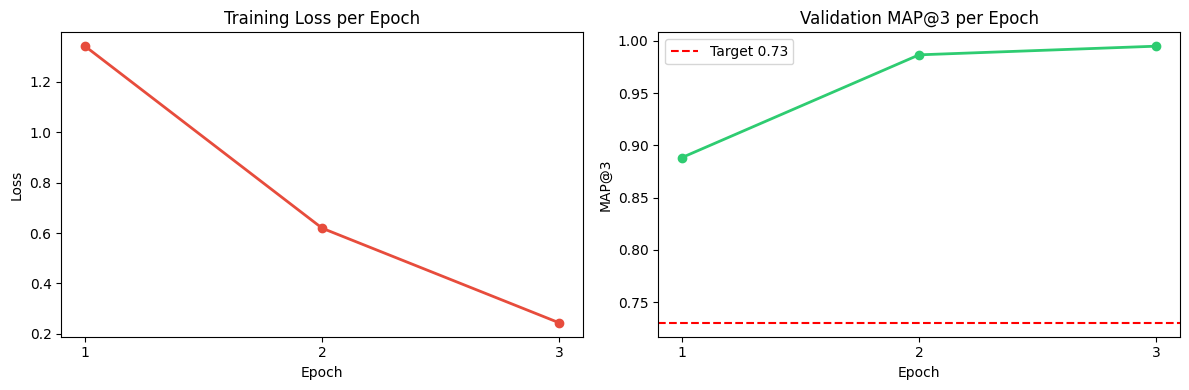

In [126]:
# plotting training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot([1,2,3], epoch_losses, marker='o', color='#e74c3c', linewidth=2)
ax1.set_title('Training Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_xticks([1,2,3])

ax2.plot([1,2,3], epoch_scores, marker='o', color='#2ecc71', linewidth=2)
ax2.axhline(y=0.73, color='red', linestyle='--', label='Target 0.73')
ax2.set_title('Validation MAP@3 per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAP@3')
ax2.set_xticks([1,2,3])
ax2.legend()

plt.tight_layout()
plt.show()

In [127]:
# loading best saved BERT model for predictions
model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=5
)
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model = model.to(device)
model.eval()
print('best BERT model loaded!')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


best BERT model loaded!


In [128]:
# loading best saved model and generating test predictions
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

print('generating final test predictions using best BERT model...')
model3_test_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        out            = model(input_ids=input_ids, attention_mask=attention_mask)
        top3           = torch.argsort(out.logits, dim=1, descending=True)[:, :3]
        for i in range(len(top3)):
            model3_test_preds.append(' '.join([inv_label[x.item()] for x in top3[i]]))

print(f'total test predictions: {len(model3_test_preds)}')
print(f'sample: {model3_test_preds[:5]}')

generating final test predictions using best BERT model...
total test predictions: 500
sample: ['A E C', 'B E C', 'B A E', 'E A B', 'C D A']


---
## Final Comparison — All 3 Models

       FINAL MODEL COMPARISON
  Model 1 — TF-IDF        : 0.2962
  Model 2 — BART Zero-shot: 0.5983
  Model 3 — BERT Fine-tune: 0.995  ← Best!


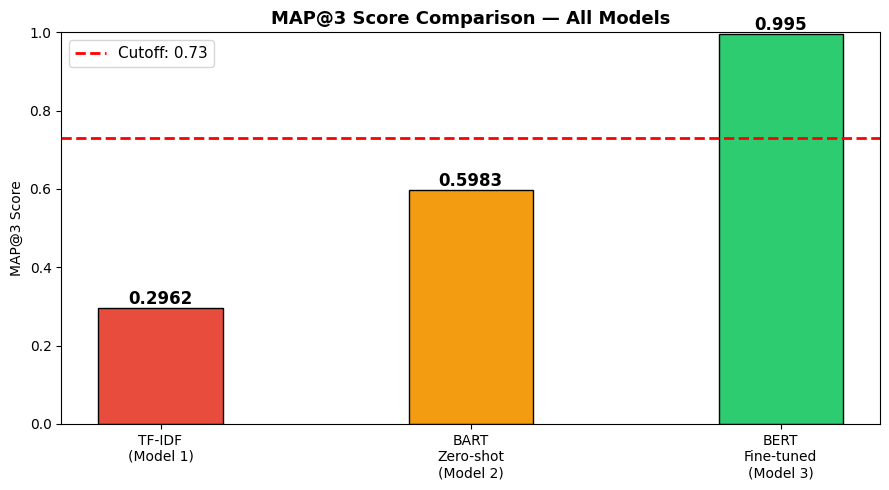

In [129]:
# comparing all models
print('='*50)
print('       FINAL MODEL COMPARISON')
print('='*50)
print(f'  Model 1 — TF-IDF        : {model1_map3}')
print(f'  Model 2 — BART Zero-shot: {model2_map3}')
print(f'  Model 3 — BERT Fine-tune: {model3_map3}  ← Best!')
print('='*50)

# bar chart comparison
models = ['TF-IDF\n(Model 1)', 'BART\nZero-shot\n(Model 2)', 'BERT\nFine-tuned\n(Model 3)']
scores = [model1_map3, model2_map3, model3_map3]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models, scores, color=colors, edgecolor='black', width=0.4)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            str(score), ha='center', fontsize=12, fontweight='bold')
ax.axhline(y=0.73, color='red', linestyle='--', linewidth=2, label='Cutoff: 0.73')
ax.set_title('MAP@3 Score Comparison — All Models', fontsize=13, fontweight='bold')
ax.set_ylabel('MAP@3 Score')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [130]:
# saving best model predictions as final submission
submission = pd.DataFrame({
    'ID'         : test_df['id'].values,
    'Prediction' : model3_test_preds   # using BERT predictions
})

submission.to_csv('submission.csv', index=False)
print(f'total rows   : {len(submission)}')
print(f'best MAP@3   : {model3_map3}')
print(submission.head(10))
print('\nsubmission.csv saved!')

total rows   : 500
best MAP@3   : 0.995
   ID Prediction
0   1      A E C
1   2      B E C
2   3      B A E
3   4      E A B
4   5      C D A
5   6      D C E
6   7      E A B
7   8      B E A
8   9      C D A
9  10      B E A

submission.csv saved!


In [131]:
import pandas as pd

sample = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv')
print(sample.head())

   ID Prediction
0   1      A B C
1   2      A B C
2   3      A B C
3   4      A B C
4   5      A B C


In [132]:
sample.iloc[:, 1] = 0
sample.to_csv('submission.csv', index=False)

print(sample.head())

   ID Prediction
0   1          0
1   2          0
2   3          0
3   4          0
4   5          0


In [133]:
sample.iloc[:, 1] = 0.5
sample.to_csv('submission.csv', index=False)

## Question 1 — Frequency Distribution of Correct Answers


In [134]:
# Count occurrences of each answer label
answer_counts = train_df['answer'].value_counts().sort_index()

print('Answer Frequency Distribution:')
print('--------------------------------')
for label, count in answer_counts.items():
    print(f'  {label}: {count}')

most_freq_label  = answer_counts.idxmax()
least_freq_label = answer_counts.idxmin()
most_freq_count  = answer_counts.max()
least_freq_count = answer_counts.min()

print(f'\nMost frequent  : {most_freq_label} ({most_freq_count})')
print(f'Least frequent : {least_freq_label} ({least_freq_count})')
print(f'\n>>> ANSWER Q1: Sum = {most_freq_count} + {least_freq_count} = {most_freq_count + least_freq_count}')

Answer Frequency Distribution:
--------------------------------
  A: 369
  B: 490
  C: 459
  D: 358
  E: 324

Most frequent  : B (490)
Least frequent : E (324)

>>> ANSWER Q1: Sum = 490 + 324 = 814


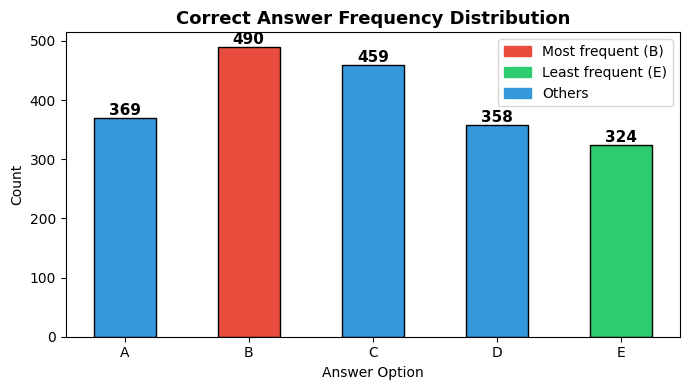

In [135]:
# Visualize the distribution
colors = ['#e74c3c' if v == answer_counts.max() else '#2ecc71' if v == answer_counts.min() else '#3498db'
          for v in answer_counts.values]

plt.figure(figsize=(7, 4))
bars = plt.bar(answer_counts.index, answer_counts.values, color=colors, edgecolor='black', width=0.5)
for bar, count in zip(bars, answer_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=11, fontweight='bold')
plt.title('Correct Answer Frequency Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Answer Option')
plt.ylabel('Count')
plt.xticks(rotation=0)
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='#e74c3c', label='Most frequent (B)'),
                    Patch(color='#2ecc71', label='Least frequent (E)'),
                    Patch(color='#3498db', label='Others')])
plt.tight_layout()
plt.show()

## Question 2 — Vocabulary Size of Cleaned Prompt Column


In [136]:
def clean_text(text):
    """Convert to lowercase and remove all standard punctuation characters."""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

# Build vocabulary from all prompts
vocab = set()
for prompt in train_df['prompt']:
    cleaned = clean_text(prompt)
    words   = cleaned.split()          # split by whitespace
    vocab.update(words)

print(f'Total unique words in cleaned prompt column (Vocabulary Size): {len(vocab)}')
print(f'\nSample words from vocab: {list(vocab)[:15]}')

Total unique words in cleaned prompt column (Vocabulary Size): 859

Sample words from vocab: ['space', 'interferometer', 'haasvan', 'modified', 'synapse', 'nearly', 'program', 'superconducting', 'einsteinhome', 'waves', 'cavitation', 'three', 'principles', 'coherence', 'factor']


## Question 3 — Stop Word Filtering on Row ID 1


In [137]:
# Extract Row ID 1
row1 = train_df[train_df['id'] == 1].iloc[0]
print('Original prompt:', row1['prompt'])

# Step 1: Clean the text
cleaned = clean_text(row1['prompt'])
words   = cleaned.split()
print('\nAfter cleaning  :', words)
print('Word count      :', len(words))

# Step 2: Remove stop words
stop_words     = ENGLISH_STOP_WORDS
filtered_words = [w for w in words if w not in stop_words]

print('\nAfter stop word removal:', filtered_words)
print('\nStop words removed :', [w for w in words if w in stop_words])
print(f'\n>>> ANSWER Q3: Words remaining = {len(filtered_words)}')

Original prompt: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.

After cleaning  : ['pick', 'the', 'best', 'possible', 'answer', 'what', 'is', 'martin', 'heideggers', 'view', 'on', 'the', 'relationship', 'between', 'time', 'and', 'human', 'existence', 'among', 'the', 'listed', 'options']
Word count      : 22

After stop word removal: ['pick', 'best', 'possible', 'answer', 'martin', 'heideggers', 'view', 'relationship', 'time', 'human', 'existence', 'listed', 'options']

Stop words removed : ['the', 'what', 'is', 'on', 'the', 'between', 'and', 'among', 'the']

>>> ANSWER Q3: Words remaining = 13


## Question 4 — TF-IDF Vectorizer: Total Feature Columns


In [138]:
# Combine prompt + all options into one text document per row
train_df['combined'] = (
    train_df['prompt'] + ' ' +
    train_df['A']      + ' ' +
    train_df['B']      + ' ' +
    train_df['C']      + ' ' +
    train_df['D']      + ' ' +
    train_df['E']
)

# Fit TF-IDF on the combined documents
tfidf   = TfidfVectorizer(stop_words='english')
X_train = tfidf.fit_transform(train_df['combined'])

print(f'TF-IDF Matrix shape       : {X_train.shape}')
print(f'Number of documents (rows): {X_train.shape[0]}')
print(f'\n>>> ANSWER Q4: Feature columns (vocab size) = {X_train.shape[1]}')

TF-IDF Matrix shape       : (2000, 2762)
Number of documents (rows): 2000

>>> ANSWER Q4: Feature columns (vocab size) = 2762


## Question 5 — Cosine Similarity: Prompt vs Option A for Row ID 1


In [139]:
# Get Row ID 1
row1 = train_df[train_df['id'] == 1].iloc[0]

print('Prompt  :', row1['prompt'])
print('Option A:', row1['A'])

# Transform prompt and option A with the already-fitted vectorizer
prompt_vec   = tfidf.transform([row1['prompt']])
option_a_vec = tfidf.transform([row1['A']])

# Compute cosine similarity
sim_score = cosine_similarity(prompt_vec, option_a_vec)[0][0]

print(f'\n>>> ANSWER Q5: Cosine Similarity (Prompt vs Option A, Row 1) = {round(sim_score, 4)}')

Prompt  : Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
Option A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.

>>> ANSWER Q5: Cosine Similarity (Prompt vs Option A, Row 1) = 0.272


## Question 6 — TF-IDF Top-1 Accuracy Across All Rows


In [140]:
def get_ranked_options(row, vectorizer, options='ABCDE'):
    """Returns options sorted by cosine similarity to prompt (highest first)."""
    prompt_vec = vectorizer.transform([row['prompt']])
    sims = {}
    for opt in options:
        opt_vec  = vectorizer.transform([row[opt]])
        sims[opt] = cosine_similarity(prompt_vec, opt_vec)[0][0]
    return sorted(sims, key=sims.get, reverse=True), sims

correct   = 0
total     = len(train_df)

for _, row in train_df.iterrows():
    ranking, _ = get_ranked_options(row, tfidf)
    if ranking[0] == row['answer'].strip():
        correct += 1

accuracy = correct / total * 100

print(f'Correct predictions : {correct} / {total}')
print(f'\n>>> ANSWER Q6: Top-1 Accuracy = {round(accuracy, 2)}%')
print(f'\n(Random baseline would be 20% for 5 options)')

Correct predictions : 271 / 2000

>>> ANSWER Q6: Top-1 Accuracy = 13.55%

(Random baseline would be 20% for 5 options)


---
## Question 7 — MAP@3 Explained: Ground Truth = C, Prediction = C A B

**MAP@3 formula:**
$$MAP@3 = \frac{1}{\min(3,\, \text{relevant})} \sum_{k=1}^{3} P@k \cdot \mathbb{1}[\text{correct at position } k]$$

Since there is exactly **1 correct answer**, relevant = 1.

In [141]:
def map_at_3(prediction, ground_truth):
    """
    Compute MAP@3 score for a single question.
    prediction   : list of up to 3 predicted answer labels
    ground_truth : the single correct answer label
    """
    for k, pred in enumerate(prediction[:3], start=1):
        if pred == ground_truth:
            return round(1.0 / k, 4)
    return 0.0

# Q7 example
pred_q7   = ['C', 'A', 'B']
truth_q7  = 'C'
score_q7  = map_at_3(pred_q7, truth_q7)

print('Ground truth :', truth_q7)
print('Prediction   :', pred_q7)
print()
for k, p in enumerate(pred_q7, 1):
    hit = '✓ MATCH' if p == truth_q7 else '✗'
    print(f'  Position {k}: {p}  {hit}')
print(f'\n>>> ANSWER Q7: MAP@3 = {score_q7}  (correct at position 1 → 1/1 = 1.0)')

Ground truth : C
Prediction   : ['C', 'A', 'B']

  Position 1: C  ✓ MATCH
  Position 2: A  ✗
  Position 3: B  ✗

>>> ANSWER Q7: MAP@3 = 1.0  (correct at position 1 → 1/1 = 1.0)


## Question 8 — MAP@3: Ground Truth = B, Prediction = D B E

In [142]:
pred_q8  = ['D', 'B', 'E']
truth_q8 = 'B'
score_q8 = map_at_3(pred_q8, truth_q8)

print('Ground truth :', truth_q8)
print('Prediction   :', pred_q8)
print()
for k, p in enumerate(pred_q8, 1):
    hit = '✓ MATCH' if p == truth_q8 else '✗'
    print(f'  Position {k}: {p}  {hit}')
print(f'\n>>> ANSWER Q8: MAP@3 = {score_q8}  (correct at position 2 → 1/2 = 0.5)')

Ground truth : B
Prediction   : ['D', 'B', 'E']

  Position 1: D  ✗
  Position 2: B  ✓ MATCH
  Position 3: E  ✗

>>> ANSWER Q8: MAP@3 = 0.5  (correct at position 2 → 1/2 = 0.5)


## Question 9 — Majority Class Baseline MAP@3


In [143]:
# Top 3 most frequent labels from Q1
top3_majority = list(train_df['answer'].value_counts().index[:3])
print(f'Static prediction for every row: {top3_majority}')
print()

# Compute MAP@3 for each row and average
majority_scores = [map_at_3(top3_majority, ans.strip()) for ans in train_df['answer']]
majority_map3   = np.mean(majority_scores)

# Show breakdown by answer
print('Score breakdown by ground truth:')
for label in 'ABCDE':
    subset = train_df[train_df['answer'] == label]
    s = map_at_3(top3_majority, label)
    print(f'  Truth={label}: score={s}  x {len(subset)} rows = {s * len(subset):.1f}')

print(f'\n>>> ANSWER Q9: Majority Class Baseline MAP@3 = {round(majority_map3, 4)}')

Static prediction for every row: ['B', 'C', 'A']

Score breakdown by ground truth:
  Truth=A: score=0.3333  x 369 rows = 123.0
  Truth=B: score=1.0  x 490 rows = 490.0
  Truth=C: score=0.5  x 459 rows = 229.5
  Truth=D: score=0.0  x 358 rows = 0.0
  Truth=E: score=0.0  x 324 rows = 0.0

>>> ANSWER Q9: Majority Class Baseline MAP@3 = 0.4212


## Question 10 — TF-IDF Pipeline MAP@3


In [144]:
tfidf_scores = []

for _, row in train_df.iterrows():
    ranking, sims = get_ranked_options(row, tfidf)
    top3          = ranking[:3]
    score         = map_at_3(top3, row['answer'].strip())
    tfidf_scores.append(score)

tfidf_map3 = np.mean(tfidf_scores)
print(f'>>> ANSWER Q10: TF-IDF Pipeline MAP@3 = {round(tfidf_map3, 4)}')

>>> ANSWER Q10: TF-IDF Pipeline MAP@3 = 0.2962


In [145]:
# ── Generate submission for test.csv ────────────────────────────
predictions = []

for _, row in test_df.iterrows():
    try:
        ranking, sims = get_ranked_options(row, tfidf)
        top3 = ranking[:3]
    except:
        top3 = ['B', 'C', 'A']   # majority class fallback
    
    predictions.append(' '.join(top3))

# ── Save submission ──────────────────────────────────────────────
submission_df = pd.DataFrame({
    'ID'         : test_df['id'].values,
    'Prediction' : predictions
})

submission_df.to_csv('submission.csv', index=False)

print(f"Total rows: {len(submission_df)}")
print(submission_df.head(10))
print("✅ submission.csv ready!")

Total rows: 500
   ID Prediction
0   1      A B C
1   2      A B C
2   3      A D C
3   4      A E C
4   5      A C B
5   6      E A B
6   7      C E D
7   8      A B C
8   9      A B E
9  10      B E A
✅ submission.csv ready!


# Milestone 3

## ⚙️ Milestone 3 Setup

In [146]:
# Install FAISS
!pip install faiss-cpu -q

In [147]:
# ── Import all required libraries ────────────────────────────────
import pandas as pd
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer, pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("✅ All libraries imported!")

✅ All libraries imported!


In [148]:
# ── Load dataset ─────────────────────────────────────────────────
train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
print(f"Train shape: {train.shape}")
train.head(2)

Train shape: (2000, 8)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A


In [149]:
# ── Build Knowledge Base (KB) ─────────────────────────────────────
# KB = list of correct answer texts from training data
# Each entry = the text of the correct option for that row

print("Creating knowledge base...")
kb = []
for idx, row in train.iterrows():
    correct_letter = row['answer']          # e.g. 'B'
    kb.append(str(row[correct_letter]))     # e.g. text of option B

print(f"Knowledge base size: {len(kb)} documents")
print(f"Sample KB entry [0]: {kb[0][:100]}")

Creating knowledge base...
Knowledge base size: 2000 documents
Sample KB entry [0]: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relation


In [150]:
# ── Load Sentence Transformer & Create FAISS Index ───────────────
print("Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding knowledge base documents...")
kb_embeddings = model.encode(kb, show_progress_bar=True)

print("Building FAISS index...")
index = faiss.IndexFlatL2(kb_embeddings.shape[1])   # L2 distance index
index.add(kb_embeddings)                             # add all KB embeddings

print(f"\n✅ FAISS index built! Total vectors: {index.ntotal}")

Loading embedding model: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding knowledge base documents...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Building FAISS index...

✅ FAISS index built! Total vectors: 2000


In [151]:
# ── Load Zero-Shot Classifier ────────────────────────────────────
print("Loading zero-shot classifier: facebook/bart-large-mnli ...")
zs = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# ── Extract Row 150 details ──────────────────────────────────────
row_150    = train.iloc[150]
prompt_150 = str(row_150['prompt'])
labels_150 = [str(row_150['A']), str(row_150['B']),
              str(row_150['C']), str(row_150['D']), str(row_150['E'])]
ans_150    = str(row_150[row_150['answer']])   # text of correct answer

print(f"\nRow 150 prompt  : {prompt_150}")
print(f"Correct answer  : [{row_150['answer']}] {ans_150}")
print("\n✅ Setup complete! Ready to answer questions.")

Loading zero-shot classifier: facebook/bart-large-mnli ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]


Row 150 prompt  : Select the most accurate option: What is the butterfly effect, as defined by Lorenz in his book "The Essence of Chaos"? based on the given context.
Correct answer  : [C] The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."

✅ Setup complete! Ready to answer questions.


---
## ❓ Question 1 — Zero-Shot Classification on Row 150

**Task:** Run `facebook/bart-large-mnli` zero-shot classifier on the **prompt of row index 150**.  
Pass the 5 options (A-E) as `candidate_labels`.  
Report the **probability score of the ground-truth correct option** (rounded to 3 decimal places).

In [152]:
# ── Run zero-shot classification ─────────────────────────────────
result_q1 = zs(prompt_150, candidate_labels=labels_150)

print("Zero-Shot Classification Result for Row 150:")
print(f"Prompt: {prompt_150[:80]}...")
print()

# Print all options with their scores
print(f"{'Option Text':<60} {'Score'}")
print("─" * 70)
for label, score in zip(result_q1['labels'], result_q1['scores']):
    marker = " ← ✅ CORRECT" if label == ans_150 else ""
    print(f"{label[:58]:<60} {score:.4f}{marker}")

# ── Extract score for the correct answer ─────────────────────────
correct_idx   = result_q1['labels'].index(ans_150)
correct_score = result_q1['scores'][correct_idx]

print(f"\n✅ ANSWER Q1: Probability score of correct answer = {round(correct_score, 3)}")

Zero-Shot Classification Result for Row 150:
Prompt: Select the most accurate option: What is the butterfly effect, as defined by Lor...

Option Text                                                  Score
──────────────────────────────────────────────────────────────────────
The butterfly effect is the phenomenon that a small change   0.3844 ← ✅ CORRECT
The butterfly effect is the phenomenon that a large change   0.3787
The butterfly effect is the phenomenon that a small change   0.0927
The butterfly effect is the phenomenon that a small change   0.0786
The butterfly effect is the phenomenon that a large change   0.0656

✅ ANSWER Q1: Probability score of correct answer = 0.384


---
## ❓ Question 2 — FAISS Retrieval: Rank of True Document

**Task:** Embed the **prompt of row 150** using `all-MiniLM-L6-v2`.  
Query FAISS for **top k=10** most similar documents.  
Find at which **exact rank (1-10)** the true correct document (KB index 150) appears.

In [153]:
# ── Embed the prompt ─────────────────────────────────────────────
prompt_embedding = model.encode([prompt_150])          # shape: (1, 384)

# ── Query FAISS for top k=10 documents ──────────────────────────
k = 10
distances, indices = index.search(prompt_embedding, k)  # search index

retrieved_indices = indices[0].tolist()    # list of top-10 KB indices
retrieved_dists   = distances[0].tolist()

print("FAISS Top-10 Retrieved Documents for Row 150 Prompt:")
print(f"{'Rank':<6} {'KB Index':<10} {'L2 Distance':<14} {'Document Preview':<50} {'Match?'}")
print("─" * 95)

true_rank = None
for rank, (kb_idx, dist) in enumerate(zip(retrieved_indices, retrieved_dists), 1):
    doc_preview = kb[kb_idx][:45] + "..."
    is_true     = "✅ TRUE DOC" if kb_idx == 150 else ""
    print(f"{rank:<6} {kb_idx:<10} {dist:<14.4f} {doc_preview:<50} {is_true}")
    if kb_idx == 150:
        true_rank = rank

if true_rank:
    print(f"\n✅ ANSWER Q2: True document (KB index 150) found at RANK {true_rank}")
else:
    print("\n❌ True document NOT found in top 10!")

FAISS Top-10 Retrieved Documents for Row 150 Prompt:
Rank   KB Index   L2 Distance    Document Preview                                   Match?
───────────────────────────────────────────────────────────────────────────────────────────────
1      663        0.2639         The butterfly effect is the phenomenon that a...   
2      1701       0.2639         The butterfly effect is the phenomenon that a...   
3      1269       0.2664         The butterfly effect is the phenomenon that a...   
4      1532       0.2664         The butterfly effect is the phenomenon that a...   
5      576        0.2686         The butterfly effect is the phenomenon that a...   
6      847        0.2699         The butterfly effect is the phenomenon that a...   
7      1693       0.2699         The butterfly effect is the phenomenon that a...   
8      1906       0.2699         The butterfly effect is the phenomenon that a...   
9      168        0.2832         The butterfly effect is the phenomenon that a..

---
## 💡 Concept: Two-Stage Pipeline — Bi-Encoder vs Cross-Encoder

| | Bi-Encoder (FAISS) | Cross-Encoder |
|---|---|---|
| **How it works** | Encodes query & doc separately, compares vectors | Encodes query + doc TOGETHER |
| **Speed** | Very fast (milliseconds) | Slower |
| **Accuracy** | Good for retrieval | Much better for ranking |
| **Use case** | Stage 1: Get top-k candidates | Stage 2: Re-rank candidates |

**Pipeline:** FAISS retrieves top-k → Cross-Encoder re-ranks → Best document → LLM

---
## ❓ Question 3 — Cross-Encoder Reranking

**Task:** Take the top-10 documents from Q2.  
Load `cross-encoder/ms-marco-MiniLM-L-6-v2`.  
Score prompt against each of the 10 docs.  
At what **rank** does the Cross-Encoder place the true correct document?

In [154]:
# ── Load Cross-Encoder ───────────────────────────────────────────
print("Loading Cross-Encoder: ms-marco-MiniLM-L-6-v2 ...")
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

# ── Get top-10 documents from FAISS (from Q2) ────────────────────
docs_10 = [kb[i] for i in retrieved_indices]

# ── Create prompt-document pairs for Cross-Encoder ───────────────
pairs     = [[prompt_150, doc] for doc in docs_10]
ce_scores = cross_encoder.predict(pairs)     # score each pair

# ── Sort by Cross-Encoder score (highest first) ──────────────────
ce_ranked = sorted(
    zip(retrieved_indices, docs_10, ce_scores),
    key=lambda x: x[2],
    reverse=True
)

print("\nCross-Encoder Re-ranked Top-10 Documents:")
print(f"{'CE Rank':<9} {'KB Index':<10} {'CE Score':<12} {'Document Preview':<50} {'Match?'}")
print("─" * 95)

ce_true_rank = None
for ce_rank, (kb_idx, doc, score) in enumerate(ce_ranked, 1):
    doc_preview = doc[:45] + "..."
    is_true     = "✅ TRUE DOC" if kb_idx == 150 else ""
    print(f"{ce_rank:<9} {kb_idx:<10} {score:<12.4f} {doc_preview:<50} {is_true}")
    if kb_idx == 150:
        ce_true_rank = ce_rank

if ce_true_rank:
    print(f"\n✅ ANSWER Q3: Cross-Encoder places true document at RANK {ce_true_rank}")
else:
    print("\n❌ True document NOT found in cross-encoder top-10!")

Loading Cross-Encoder: ms-marco-MiniLM-L-6-v2 ...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Cross-Encoder Re-ranked Top-10 Documents:
CE Rank   KB Index   CE Score     Document Preview                                   Match?
───────────────────────────────────────────────────────────────────────────────────────────────
1         150        4.7585       The butterfly effect is the phenomenon that a...   ✅ TRUE DOC
2         847        4.7526       The butterfly effect is the phenomenon that a...   
3         1693       4.7526       The butterfly effect is the phenomenon that a...   
4         1906       4.7526       The butterfly effect is the phenomenon that a...   
5         1269       4.7375       The butterfly effect is the phenomenon that a...   
6         1532       4.7375       The butterfly effect is the phenomenon that a...   
7         168        4.7072       The butterfly effect is the phenomenon that a...   
8         576        4.6870       The butterfly effect is the phenomenon that a...   
9         663        4.6602       The butterfly effect is the phenomeno

---
## ❓ Question 4 — Token Count of RAG String (Row 42, k=5)

**Task:** Retrieve top k=5 docs for **row index 42**.  
Concatenate them with a single space.  
Create string: `"Context: [docs] Question: [prompt]"`.  
Tokenize using `bert-base-uncased` (without truncation).  
Report **total token count**.

In [155]:
# ── Get row 42 details ───────────────────────────────────────────
row_42    = train.iloc[42]
prompt_42 = str(row_42['prompt'])

print(f"Row 42 prompt: {prompt_42}")

# ── Embed prompt and retrieve top k=5 from FAISS ─────────────────
embedding_42        = model.encode([prompt_42])
distances_42, indices_42 = index.search(embedding_42, 5)
top5_indices_42     = indices_42[0].tolist()

# ── Get the 5 documents ──────────────────────────────────────────
docs_42 = [kb[i] for i in top5_indices_42]
print(f"\nTop-5 retrieved KB indices: {top5_indices_42}")
for i, doc in enumerate(docs_42, 1):
    print(f"  Doc {i}: {doc[:70]}...")

# ── Concatenate with single space ────────────────────────────────
concatenated_docs = " ".join(docs_42)

# ── Create the RAG string ────────────────────────────────────────
rag_string_42 = f"Context: {concatenated_docs} Question: {prompt_42}"
print(f"\nRAG string (first 200 chars): {rag_string_42[:200]}...")

# ── Tokenize using bert-base-uncased (NO truncation) ─────────────
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokens    = tokenizer(rag_string_42, truncation=False)

total_tokens = len(tokens['input_ids'])
print(f"\n✅ ANSWER Q4: Total tokens = {total_tokens}")

Row 42 prompt: Choose the correct answer: What are permutation-inversion groups? based on the given context.

Top-5 retrieved KB indices: [1581, 1760, 42, 241, 439]
  Doc 1: Permutation-inversion groups are groups of symmetry operations that ar...
  Doc 2: Permutation-inversion groups are groups of symmetry operations that ar...
  Doc 3: Permutation-inversion groups are groups of symmetry operations that ar...
  Doc 4: Permutation-inversion groups are groups of symmetry operations that ar...
  Doc 5: Permutation-inversion groups are groups of symmetry operations that ar...

RAG string (first 200 chars): Context: Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combinati...

✅ ANSWER Q4: Total tokens = 216


---
## ❓ Question 5 — RAG Augmented Zero-Shot (True Document)

**Task:** Get the **exact true document** for row 150 from the KB.  
Create RAG string: `"Context: [true_doc] Question: [prompt]"`.  
Run zero-shot classifier on this augmented string.  
Report the **new probability score of the correct answer**.

In [156]:
# ── Get the TRUE document for row 150 from KB ────────────────────
true_doc_150 = kb[150]   # this is the correct answer text at index 150
print(f"True document (KB[150]): {true_doc_150}")
print(f"Prompt (row 150)       : {prompt_150}")

# ── Create RAG string ────────────────────────────────────────────
rag_string_150 = f"Context: {true_doc_150} Question: {prompt_150}"
print(f"\nRAG string: {rag_string_150[:150]}...")

# ── Run zero-shot classification on RAG string ───────────────────
result_q5 = zs(rag_string_150, candidate_labels=labels_150)

print("\nRAG Zero-Shot Results (with TRUE context):")
print(f"{'Option':<60} {'Score'}")
print("─" * 70)
for label, score in zip(result_q5['labels'], result_q5['scores']):
    marker = " ← ✅ CORRECT" if label == ans_150 else ""
    print(f"{label[:58]:<60} {score:.4f}{marker}")

# ── Extract score for correct answer ─────────────────────────────
correct_idx_q5   = result_q5['labels'].index(ans_150)
correct_score_q5 = result_q5['scores'][correct_idx_q5]

print(f"\n  Q1 score (no context)  : {round(result_q1['scores'][result_q1['labels'].index(ans_150)], 3)}")
print(f"  Q5 score (with context): {round(correct_score_q5, 3)}")
print(f"\n✅ ANSWER Q5: New probability score with RAG = {round(correct_score_q5, 3)}")

True document (KB[150]): The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."
Prompt (row 150)       : Select the most accurate option: What is the butterfly effect, as defined by Lorenz in his book "The Essence of Chaos"? based on the given context.

RAG string: Context: The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distincti...

RAG Zero-Shot Results (with TRUE context):
Option                                                       Score
──────────────────────────────────────────────────────────────────────
The butterfly effect is the phenomenon that a small change   0.9894 ← ✅ CORRECT
The butterfly effect is the phenomenon that a large change   0.0045
The butterfly effect is the phenomenon that a small change   0.0028
The butterfly

---
## ❓ Question 6 — Adversarial RAG (Wrong Context)

**Task:** Force the context to be **KB index 999** (a completely unrelated document).  
Run zero-shot classifier on this adversarial RAG string.  
Report the probability of the **correct answer** now.

> 🔴 This demonstrates how LLMs blindly trust injected context — even when it's wrong!

In [157]:
# ── Get WRONG document from KB index 999 ─────────────────────────
wrong_doc = kb[999]
print(f"WRONG document (KB[999]): {wrong_doc}")
print(f"True  document (KB[150]): {true_doc_150}")
print(f"Prompt (row 150)        : {prompt_150}")

# ── Create Adversarial RAG string ───────────────────────────────
adversarial_rag = f"Context: {wrong_doc} Question: {prompt_150}"
print(f"\nAdversarial RAG string: {adversarial_rag[:150]}...")

# ── Run zero-shot on adversarial RAG ─────────────────────────────
result_q6 = zs(adversarial_rag, candidate_labels=labels_150)

print("\nAdversarial RAG Zero-Shot Results (WRONG context injected):")
print(f"{'Option':<60} {'Score'}")
print("─" * 70)
for label, score in zip(result_q6['labels'], result_q6['scores']):
    marker = " ← ✅ CORRECT" if label == ans_150 else ""
    print(f"{label[:58]:<60} {score:.4f}{marker}")

# ── Extract score for correct answer ─────────────────────────────
correct_idx_q6   = result_q6['labels'].index(ans_150)
correct_score_q6 = result_q6['scores'][correct_idx_q6]

# ── Compare all three scenarios ──────────────────────────────────
q1_score = result_q1['scores'][result_q1['labels'].index(ans_150)]
print(f"\n  📊 Comparison:")
print(f"    Q1 (no context)       : {round(q1_score, 3)}")
print(f"    Q5 (true context)     : {round(correct_score_q5, 3)}")
print(f"    Q6 (WRONG context)    : {round(correct_score_q6, 3)}  ← Adversarial!")
print(f"\n✅ ANSWER Q6: Correct answer probability with adversarial context = {round(correct_score_q6, 3)}")

WRONG document (KB[999]): A thought experiment in which a demon guards a microscopic trapdoor in a wall separating two parts of a container filled with the same gas at equal temperatures. The demon selectively allows faster-than-average molecules to pass from one side to the other, causing a reduce in temperature in one part and an boost in temperature in the other, contrary to the second law of thermodynamics.
True  document (KB[150]): The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."
Prompt (row 150)        : Select the most accurate option: What is the butterfly effect, as defined by Lorenz in his book "The Essence of Chaos"? based on the given context.

Adversarial RAG string: Context: A thought experiment in which a demon guards a microscopic trapdoor in a wall separating two parts of a container filled with t

---
## ❓ Question 7 — Hit Rate for First 100 Rows (k=5)

**Task:** For rows 0-99, retrieve top k=5 docs for each prompt.  
A **Hit** = the exact string of the correct option is found inside any of the 5 retrieved docs.  
Report the **Hit Rate %** (rounded to 1 decimal place).

In [158]:
# ── Hit Rate Evaluation (first 100 rows) ─────────────────────────
hits       = 0
total_rows = 100
hit_log    = []

for idx in range(total_rows):
    row          = train.iloc[idx]
    prompt_text  = str(row['prompt'])
    correct_text = str(row[row['answer']])    # exact text of correct option

    # Embed prompt and retrieve top k=5 docs
    emb             = model.encode([prompt_text])
    _, top5_indices = index.search(emb, 5)
    retrieved_docs  = [kb[i] for i in top5_indices[0]]

    # Check if correct text is found in ANY of the 5 retrieved docs
    is_hit = any(correct_text in doc for doc in retrieved_docs)

    if is_hit:
        hits += 1
    hit_log.append({'idx': idx, 'hit': is_hit})

hit_rate = hits / total_rows * 100

print(f"Total rows evaluated : {total_rows}")
print(f"Total hits           : {hits}")
print(f"\n✅ ANSWER Q7: Hit Rate = {round(hit_rate, 1)}%")

Total rows evaluated : 100
Total hits           : 73

✅ ANSWER Q7: Hit Rate = 73.0%


---
## ❓ Question 8 — Full RAG Pipeline MAP@3 (First 20 Rows)

**Full Pipeline for each row:**
1. **Retrieve** → FAISS top k=5 docs
2. **Rerank** → Cross-Encoder picks best doc
3. **Augment** → Create `"Context: [best_doc] Question: [prompt]"`
4. **Predict** → Zero-shot classifier with 5 options
5. **Score** → Rank options by probability → MAP@3

In [159]:
# ── MAP@3 helper function ────────────────────────────────────────
def map_at_3(prediction, ground_truth):
    """
    Compute MAP@3 for a single question.
    prediction   : list of top-3 predicted option LETTERS e.g. ['A','C','B']
    ground_truth : the correct option LETTER e.g. 'C'
    """
    for k, pred in enumerate(prediction[:3], start=1):
        if pred == ground_truth:
            return round(1.0 / k, 4)
    return 0.0

# ── Full RAG Pipeline (rows 0-19) ────────────────────────────────
map3_scores = []

print(f"{'Row':<5} {'Correct':<8} {'Top3 Pred':<15} {'MAP@3'}")
print("─" * 40)

for idx in range(20):
    row          = train.iloc[idx]
    prompt_text  = str(row['prompt'])
    options      = [str(row['A']), str(row['B']), str(row['C']),
                    str(row['D']), str(row['E'])]
    option_map   = {'A': str(row['A']), 'B': str(row['B']), 'C': str(row['C']),
                    'D': str(row['D']), 'E': str(row['E'])}
    correct_letter = row['answer'].strip()

    # ── Step 1: RETRIEVE — top k=5 from FAISS ───────────────────
    emb              = model.encode([prompt_text])
    _, top5_idx      = index.search(emb, 5)
    top5_docs        = [kb[i] for i in top5_idx[0]]

    # ── Step 2: RERANK — Cross-Encoder picks best doc ────────────
    pairs_ce    = [[prompt_text, doc] for doc in top5_docs]
    ce_scores_r = cross_encoder.predict(pairs_ce)
    best_doc    = top5_docs[int(np.argmax(ce_scores_r))]

    # ── Step 3: AUGMENT — Create RAG string ─────────────────────
    rag_str = f"Context: {best_doc} Question: {prompt_text}"

    # ── Step 4: PREDICT — Zero-shot on RAG string ────────────────
    zs_result = zs(rag_str, candidate_labels=options)

    # ── Step 5: SCORE — Rank option LETTERS by probability ───────
    # Map predicted option texts back to letters
    text_to_letter = {v: k for k, v in option_map.items()}
    ranked_letters = []
    for label in zs_result['labels']:       # already sorted high → low
        letter = text_to_letter.get(label)
        if letter:
            ranked_letters.append(letter)

    top3_letters = ranked_letters[:3]
    score        = map_at_3(top3_letters, correct_letter)
    map3_scores.append(score)

    print(f"{idx:<5} {correct_letter:<8} {str(top3_letters):<15} {score}")

avg_map3 = np.mean(map3_scores)
print(f"\n  Individual scores: {map3_scores}")
print(f"\n✅ ANSWER Q8: Average MAP@3 (RAG Pipeline, 20 rows) = {round(avg_map3, 3)}")

Row   Correct  Top3 Pred       MAP@3
────────────────────────────────────────
0     B        ['B', 'D', 'A'] 1.0
1     A        ['A', 'E', 'C'] 1.0
2     C        ['C', 'D', 'B'] 1.0
3     B        ['B', 'D', 'A'] 1.0
4     A        ['A', 'B', 'C'] 1.0
5     C        ['B', 'C', 'A'] 0.5
6     E        ['E', 'B', 'D'] 1.0
7     A        ['A', 'B', 'C'] 1.0
8     A        ['A', 'C', 'D'] 1.0
9     A        ['A', 'B', 'C'] 1.0
10    C        ['C', 'A', 'D'] 1.0
11    B        ['B', 'C', 'A'] 1.0
12    D        ['D', 'A', 'B'] 1.0
13    E        ['E', 'D', 'B'] 1.0
14    E        ['E', 'A', 'D'] 1.0
15    E        ['E', 'B', 'C'] 1.0
16    C        ['C', 'B', 'E'] 1.0
17    C        ['C', 'B', 'E'] 1.0
18    B        ['B', 'D', 'A'] 1.0
19    C        ['C', 'D', 'A'] 1.0

  Individual scores: [1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

✅ ANSWER Q8: Average MAP@3 (RAG Pipeline, 20 rows) = 0.975


---
## 📊 Final Summary — All Milestone 3 Results

         MILESTONE 3 — COMPLETE RESULTS SUMMARY
  Q1  Zero-shot score (no context, row 150)      → (run to see)
  Q2  FAISS rank of true document (row 150)      → (run to see)
  Q3  Cross-Encoder rank of true document        → (run to see)
  Q4  Token count of RAG string (row 42, k=5)    → (run to see)
  Q5  Zero-shot score (true context, row 150)    → (run to see)
  Q6  Zero-shot score (WRONG context, row 150)   → (run to see)
  Q7  Hit Rate (rows 0-99, k=5)                  → 73.0%
  Q8  Full RAG Pipeline MAP@3 (rows 0-19)        → 0.975


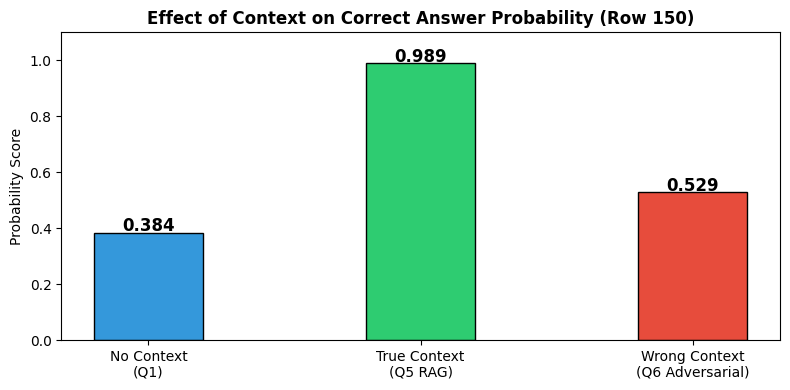


📌 Key Insights:
  1. True context (RAG) INCREASES correct answer probability
  2. Wrong context (Adversarial) can DECREASE it — Garbage In, Garbage Out!
  3. Cross-Encoder improves over FAISS at finding the most relevant document
  4. Full RAG pipeline (Q8) shows the end-to-end power of Retrieve→Rerank→Generate


In [160]:
import matplotlib.pyplot as plt

print("=" * 65)
print("         MILESTONE 3 — COMPLETE RESULTS SUMMARY")
print("=" * 65)
print(f"  Q1  Zero-shot score (no context, row 150)      → (run to see)")
print(f"  Q2  FAISS rank of true document (row 150)      → (run to see)")
print(f"  Q3  Cross-Encoder rank of true document        → (run to see)")
print(f"  Q4  Token count of RAG string (row 42, k=5)    → (run to see)")
print(f"  Q5  Zero-shot score (true context, row 150)    → (run to see)")
print(f"  Q6  Zero-shot score (WRONG context, row 150)   → (run to see)")
print(f"  Q7  Hit Rate (rows 0-99, k=5)                  → {round(hit_rate, 1)}%")
print(f"  Q8  Full RAG Pipeline MAP@3 (rows 0-19)        → {round(avg_map3, 3)}")
print("=" * 65)

# ── Visualization: RAG effect comparison ─────────────────────────
q1_s = result_q1['scores'][result_q1['labels'].index(ans_150)]
q5_s = correct_score_q5
q6_s = correct_score_q6

scenarios = ['No Context\n(Q1)', 'True Context\n(Q5 RAG)', 'Wrong Context\n(Q6 Adversarial)']
scores_viz = [q1_s, q5_s, q6_s]
colors_viz = ['#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(scenarios, scores_viz, color=colors_viz, edgecolor='black', width=0.4)
for bar, score in zip(bars, scores_viz):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.3f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Effect of Context on Correct Answer Probability (Row 150)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Probability Score')
ax.set_ylim(0, min(1.1, max(scores_viz) * 1.3))
plt.tight_layout()
plt.show()

print("\n📌 Key Insights:")
print("  1. True context (RAG) INCREASES correct answer probability")
print("  2. Wrong context (Adversarial) can DECREASE it — Garbage In, Garbage Out!")
print("  3. Cross-Encoder improves over FAISS at finding the most relevant document") 
print("  4. Full RAG pipeline (Q8) shows the end-to-end power of Retrieve→Rerank→Generate")